#                            ________________________     Customer Churn Analysis Project  _____________________

# Import Liberaries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [2]:
df = pd.read_csv('customer_churn_.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.isnull().sum().sum()

np.int64(0)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [9]:
df.shape

(7043, 21)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [13]:
df.isnull().sum().sum()

np.int64(11)

In [14]:
df.dropna(inplace=True)

In [15]:
df.isnull().sum().sum()

np.int64(0)

In [16]:
df["Churn"].value_counts()

,count
Churn,
No,5163
Yes,1869


In [60]:
# Example cleaning steps
df = df.drop_duplicates()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [58]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

/tmp/ipykernel_1485/194526705.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")


# Outlier

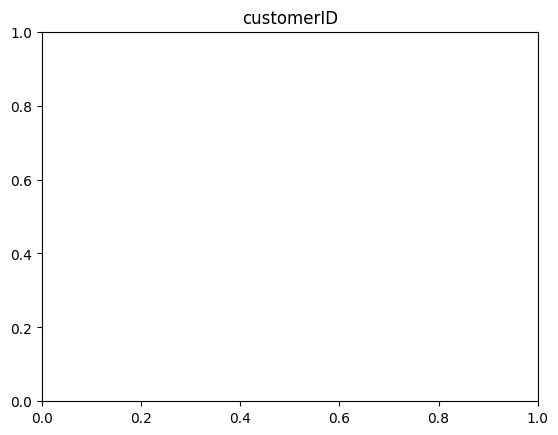

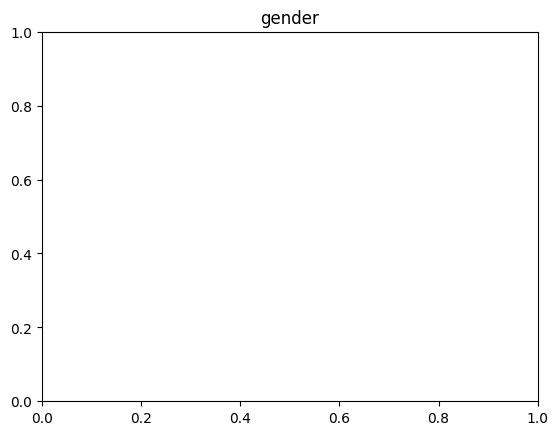

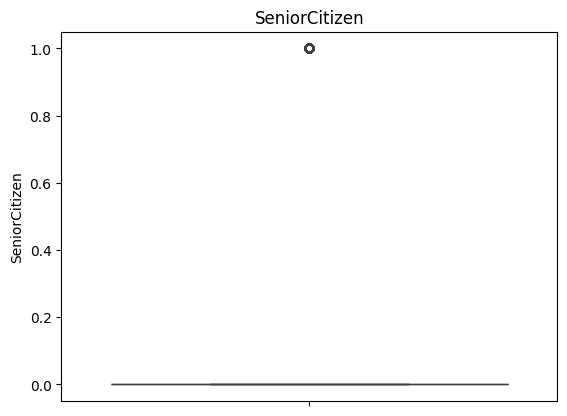

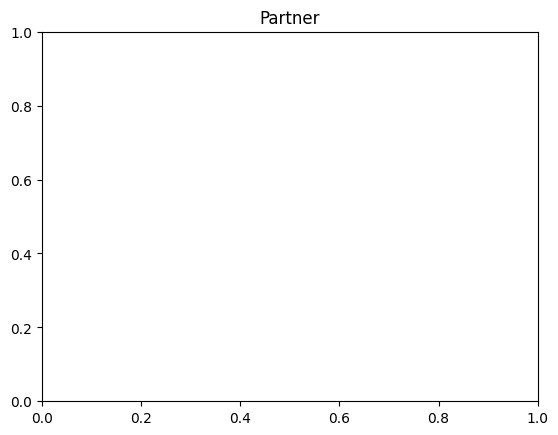

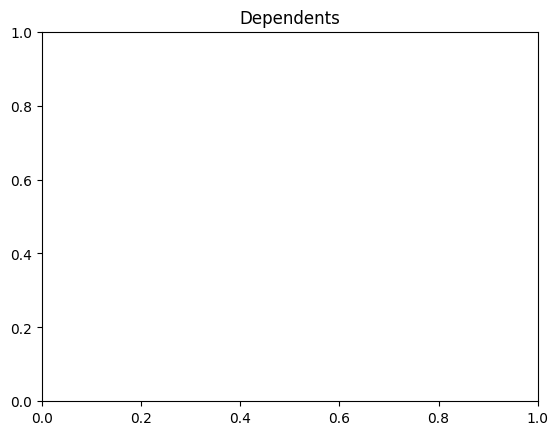

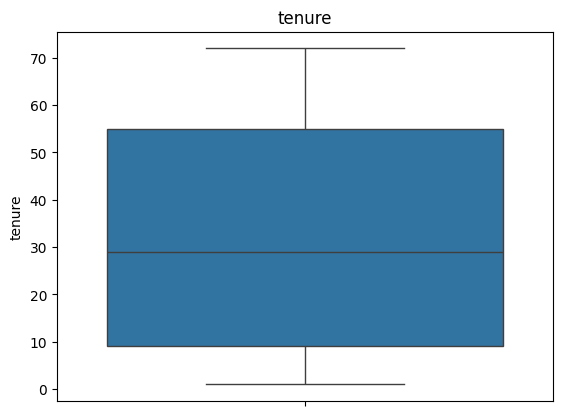

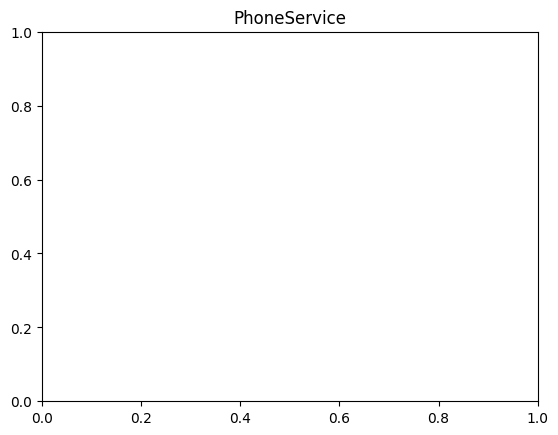

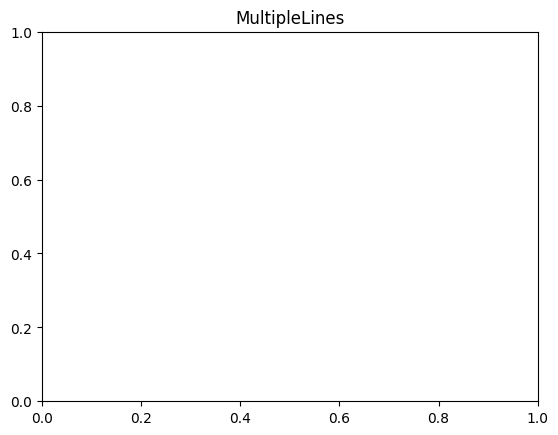

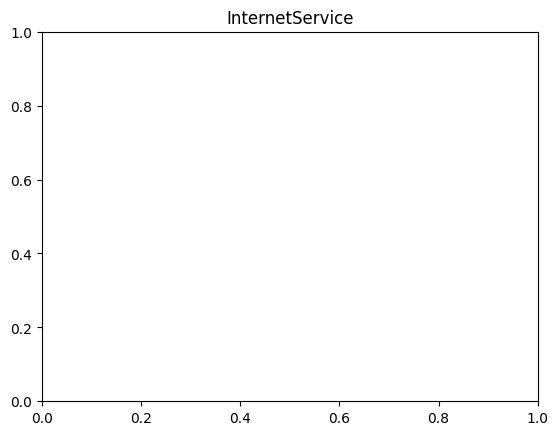

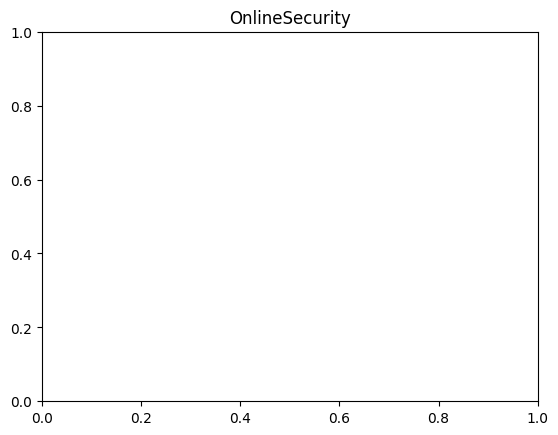

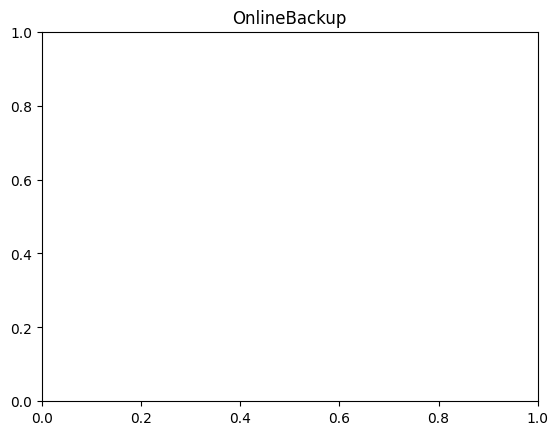

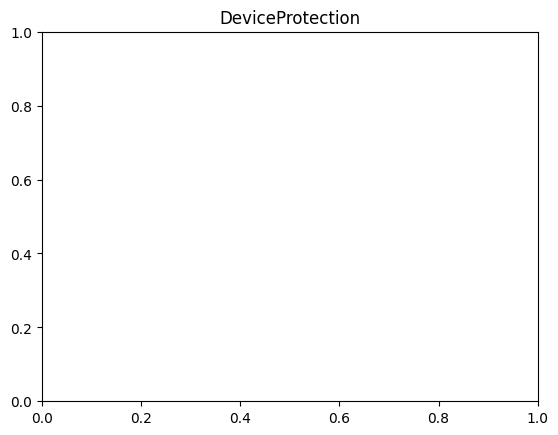

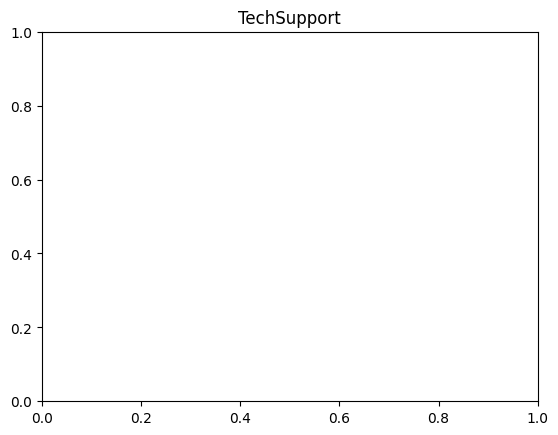

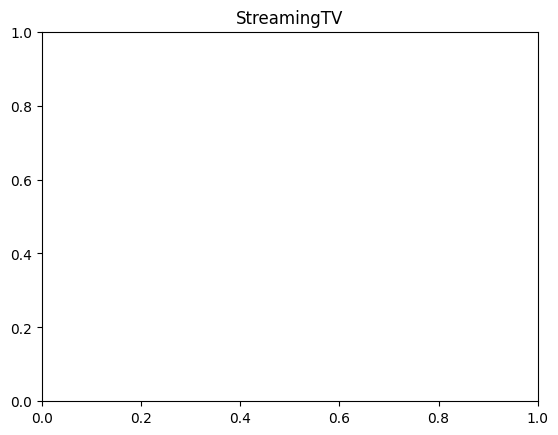

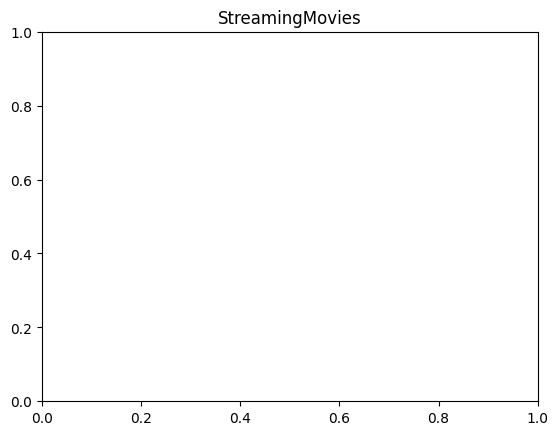

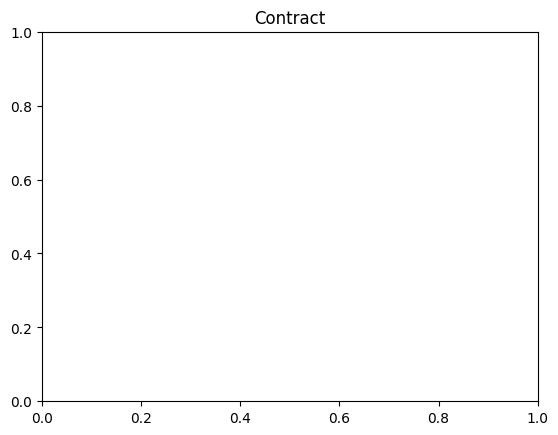

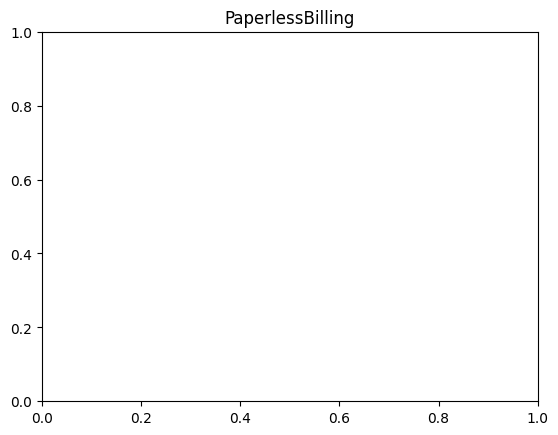

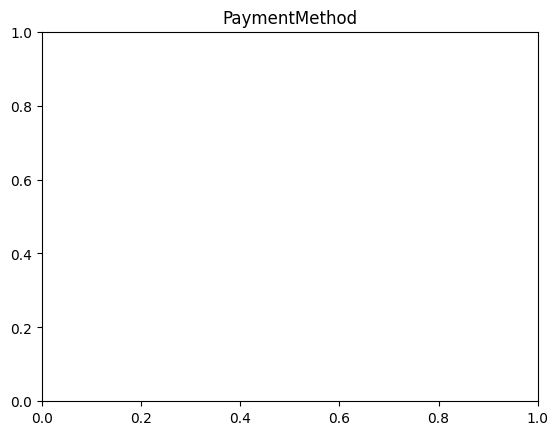

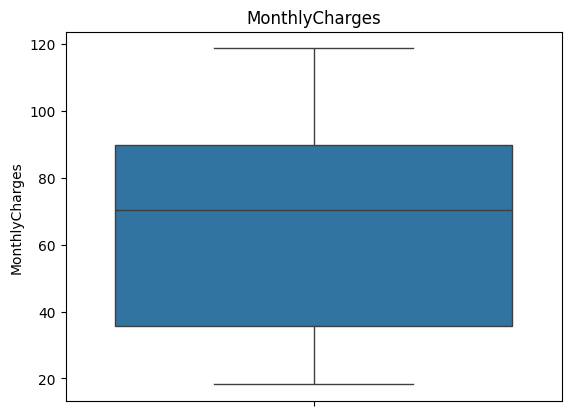

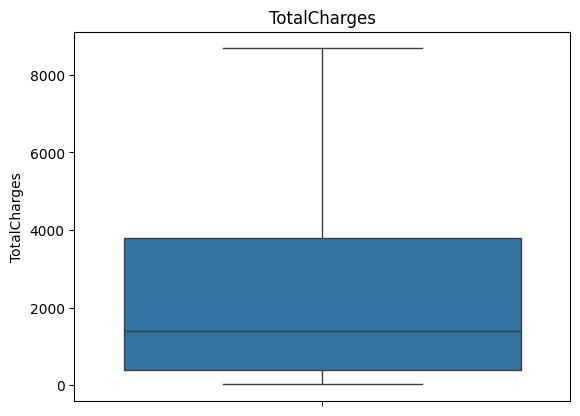

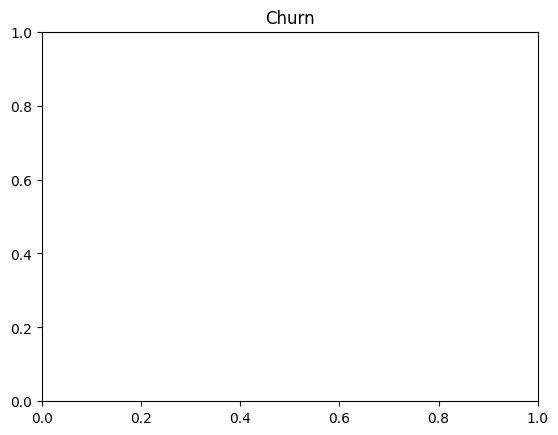

In [18]:
for col in df.columns:
    if df[col].dtype != 'object':
        sns.boxplot(df[col])
    plt.title(col)
    plt.show()

In [19]:
df.drop(['customerID'],axis = 1,  inplace=True)

In [20]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


# EDA

# 1. Churn Distribution

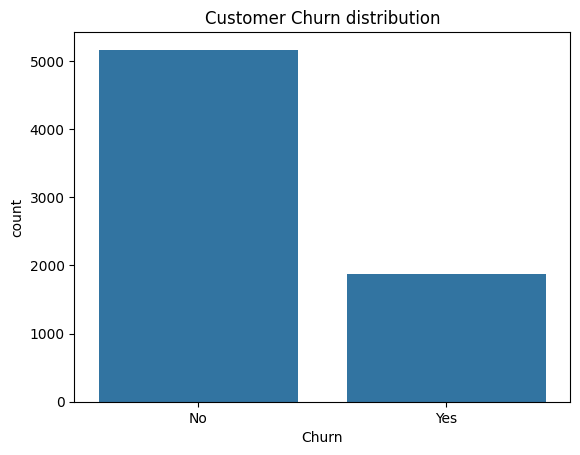

In [21]:
sns.countplot(x = 'Churn', data = df)
plt.title('Customer Churn distribution')
plt.show()

# 2. Gender vs Churn

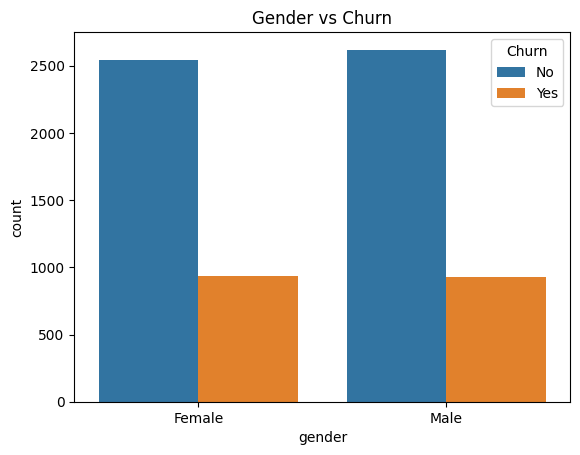

In [22]:
sns.countplot(x= 'gender', data = df, hue = 'Churn' )
plt.title('Gender vs Churn')
plt.show()

# 3. SeniorCitizen vs Churn

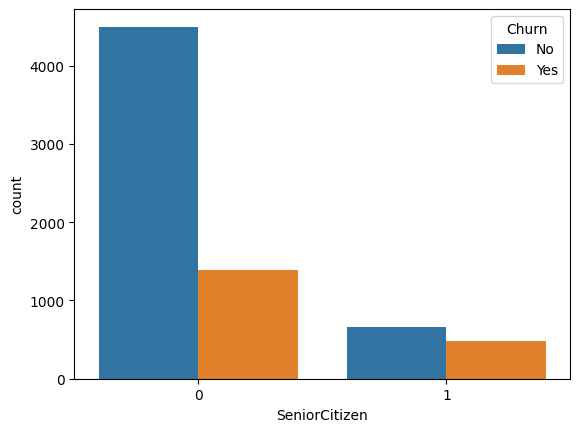

In [23]:
sns.countplot(x= 'SeniorCitizen', data = df, hue = 'Churn' )
plt.show()

# Contract vs Churn

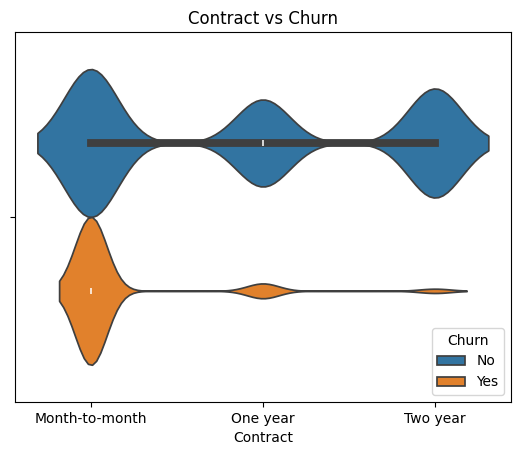

In [24]:
sns.violinplot(x= 'Contract', data = df, hue = 'Churn' )
plt.title('Contract vs Churn')
plt.show()

# PaymentMethod vs Churn

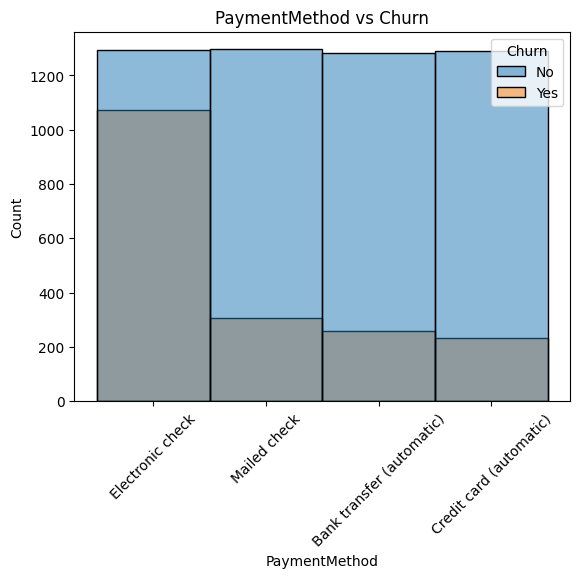

In [25]:
sns.histplot(x= 'PaymentMethod', data = df, hue = 'Churn' )
plt.xticks(rotation=45)
plt.title('PaymentMethod vs Churn')
plt.show()

# Internet Service vs Churn

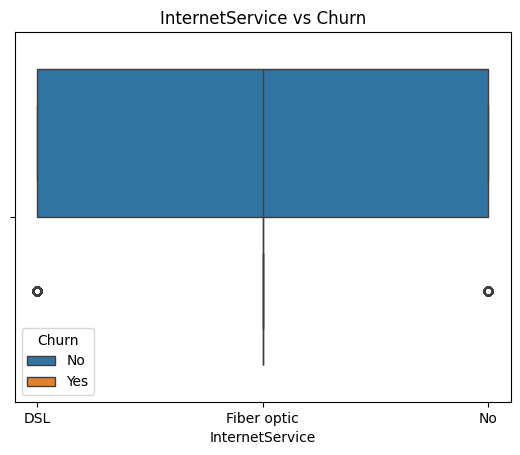

In [26]:
sns.boxplot(x= 'InternetService', data = df, hue = 'Churn' )
#  plt.xticks(rotation=45)
plt.title('InternetService vs Churn')
plt.show()

# Monthly Charges vs Churn

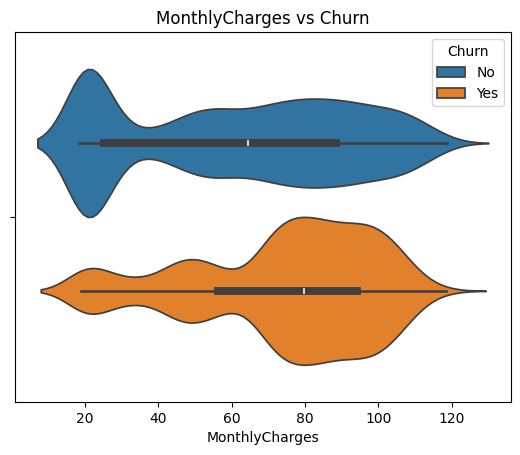

In [27]:
sns.violinplot(x= 'MonthlyCharges', data = df, hue = 'Churn' )
# plt.xticks(rotation=45)
plt.title('MonthlyCharges vs Churn')
plt.show()

# Tenture Vs Churn

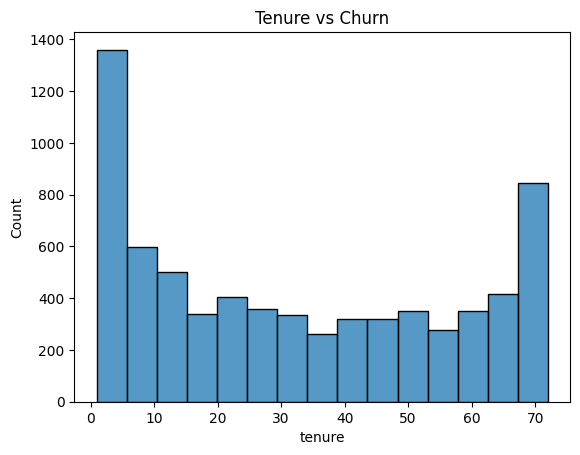

In [28]:
sns.histplot(x= 'tenure', data = df )
# plt.xticks(rotation=45)
plt.title('Tenure vs Churn')
plt.show()

In [62]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define numerical and categorical features based on the dataframe's state before LabelEncoder
# assuming 'df' still contains original categorical columns and 'customerID' is dropped, 'TotalCharges' is numeric.
numeric_features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Label Incoder

In [29]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [30]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col]=le.fit_transform(df[col].astype(str))

In [31]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50,0
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90,0
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45,0
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60,1


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   int64  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int64  
 3   Dependents        7032 non-null   int64  
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   int64  
 6   MultipleLines     7032 non-null   int64  
 7   InternetService   7032 non-null   int64  
 8   OnlineSecurity    7032 non-null   int64  
 9   OnlineBackup      7032 non-null   int64  
 10  DeviceProtection  7032 non-null   int64  
 11  TechSupport       7032 non-null   int64  
 12  StreamingTV       7032 non-null   int64  
 13  StreamingMovies   7032 non-null   int64  
 14  Contract          7032 non-null   int64  
 15  PaperlessBilling  7032 non-null   int64  
 16  PaymentMethod     7032 non-null   int64  
 17  

# Feature Selection

In [33]:
# input feature
x = df.drop('Churn',axis =1)
# x = df.iloc[:,:-1]
# output/Target
y = df['Churn']

# Train Test Split

In [34]:
from sklearn.model_selection import train_test_split

In [63]:
x_train,x_test,y_train,y_test=train_test_split(x,y , test_size = 0.20, random_state=42)

In [36]:
x_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
2964,1,0,1,0,24,1,2,0,2,0,0,2,0,0,1,1,2,58.35,1346.90
5113,0,0,1,1,71,1,2,1,2,2,2,2,2,2,2,0,1,113.65,8166.80
5363,1,0,1,1,70,1,2,2,1,1,1,1,1,1,2,0,3,25.35,1715.15
5074,0,0,0,1,49,1,0,2,1,1,1,1,1,1,1,0,1,19.45,921.30
156,0,0,0,0,22,1,2,1,0,0,0,0,2,0,0,1,0,84.15,1821.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4939,1,0,0,0,1,1,0,2,1,1,1,1,1,1,0,0,3,18.90,18.90
3269,1,0,0,0,65,1,2,2,1,1,1,1,1,1,1,0,1,24.80,1600.95
1658,1,0,1,1,50,1,2,1,2,0,2,0,2,2,0,0,1,105.95,5341.80
2612,0,0,1,1,14,1,2,0,0,2,0,2,2,2,0,0,1,80.45,1137.05


In [37]:
y_train

,Churn
2964,0
5113,0
5363,0
5074,0
156,0
...,...
4939,0
3269,0
1658,1
2612,0


In [38]:
x_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
5561,1,0,0,0,1,1,0,2,1,1,1,1,1,1,0,0,2,20.65,20.65
5814,1,0,0,0,16,1,0,2,1,1,1,1,1,1,0,1,1,20.60,330.25
2645,0,0,0,0,1,1,0,2,1,1,1,1,1,1,0,0,1,19.80,19.80
3983,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,2,24.25,24.25
6438,1,1,0,0,1,1,2,1,0,0,0,0,0,0,0,1,2,74.40,74.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2757,0,0,1,1,69,1,2,1,2,0,2,0,0,0,1,0,0,84.45,5848.60
5702,1,1,1,1,71,1,2,1,2,2,0,0,2,2,0,1,1,105.10,7548.10
1662,1,0,0,0,5,1,0,1,0,0,0,0,0,0,0,1,2,69.75,324.60
2766,0,0,1,0,64,1,2,1,2,2,2,2,2,2,1,1,2,115.00,7396.15


In [39]:
y_test

,Churn
5561,0
5814,0
2645,0
3983,1
6438,1
...,...
2757,0
5702,1
1662,1
2766,0


# VIF

In [40]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_df= pd.DataFrame()

In [41]:
vif_df['Features'] = x.columns
vif_df

,Features
0,gender
1,SeniorCitizen
2,Partner
3,Dependents
4,tenure
5,PhoneService
6,MultipleLines
7,InternetService
8,OnlineSecurity
9,OnlineBackup


In [42]:
vif_df = pd.DataFrame()
vif_df['Features']=x.columns
vif_df['Multicollinearity'] = [variance_inflation_factor(x.values,i) for i in range (len(x.columns))]

In [43]:
vif_df

,Features,Multicollinearity
0,gender,1.001876
1,SeniorCitizen,1.149648
2,Partner,1.461171
3,Dependents,1.379721
4,tenure,7.493654
5,PhoneService,1.622695
6,MultipleLines,1.395898
7,InternetService,1.824359
8,OnlineSecurity,1.268758
9,OnlineBackup,1.219068


# Logistic Regression  

In [44]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [45]:
lr.fit(x_train,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [46]:
y_pred = lr.predict(x_test)

In [47]:
y_pred

array([0, 0, 0, ..., 1, 0, 1])

In [48]:
x_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
5561,1,0,0,0,1,1,0,2,1,1,1,1,1,1,0,0,2,20.65,20.65
5814,1,0,0,0,16,1,0,2,1,1,1,1,1,1,0,1,1,20.60,330.25
2645,0,0,0,0,1,1,0,2,1,1,1,1,1,1,0,0,1,19.80,19.80
3983,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,2,24.25,24.25
6438,1,1,0,0,1,1,2,1,0,0,0,0,0,0,0,1,2,74.40,74.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2757,0,0,1,1,69,1,2,1,2,0,2,0,0,0,1,0,0,84.45,5848.60
5702,1,1,1,1,71,1,2,1,2,2,0,0,2,2,0,1,1,105.10,7548.10
1662,1,0,0,0,5,1,0,1,0,0,0,0,0,0,0,1,2,69.75,324.60
2766,0,0,1,0,64,1,2,1,2,2,2,2,2,2,1,1,2,115.00,7396.15


# Decision Tree

In [49]:
from sklearn. tree  import DecisionTreeClassifier
model = DecisionTreeClassifier()

model.fit(x_train,y_train)

DecisionTreeClassifier()

In [50]:
y_pred = model.predict(x_test)

In [51]:
y_pred

array([0, 0, 0, ..., 1, 0, 1])

# Accuracy Comparison

In [52]:
from sklearn.metrics import *
accuracy_score(y_pred,y_test)

0.7171286425017769

 # Confusion Matrix

<Axes: >

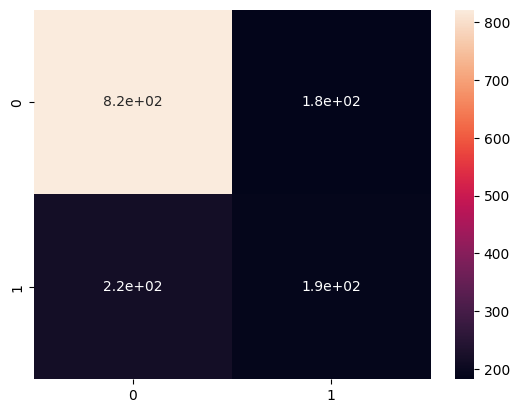

In [53]:
cf = confusion_matrix(y_pred,y_test)
sns.heatmap(cf,annot=True)

# Classification report

In [54]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.79      0.81      1038
           1       0.46      0.51      0.48       369

    accuracy                           0.72      1407
   macro avg       0.64      0.65      0.64      1407
weighted avg       0.73      0.72      0.72      1407



# Accuracy Score

In [55]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.7171286425017769

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

model.fit(x_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

In [66]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "classifier__n_estimators":,
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__min_samples_split": [2, 5, 10]
}

search = RandomizedSearchCV(
    model,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring="f1",
    random_state=42
)

search.fit(x_train, y_train)


SyntaxError: expression expected after dictionary key and ':' (1170622202.py, line 4)